In [1]:
import torch
import math
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms, datasets

In [2]:
LEARNING_RATE = 0.001
TRAIN_PATH = '../../flower_dataset/train'
VAL_PATH = '../../flower_dataset/valid'
TEST_PATH = '../../flower_dataset/test'
BATCH_SIZE = 32
EPOCH = 40

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean = [0.5, 0.5, 0.5],
        std = [0.5, 0.5, 0.5]
    )
])

train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=data_transform)
val_dataset = datasets.ImageFolder(root=VAL_PATH, transform=data_transform)
test_dataset = datasets.ImageFolder(root=TEST_PATH, transform=data_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [4]:
class WindowAttention(nn.Module):
    def __init__(self, dim, window_size, num_heads):
        super().__init__()
        self.window_size = window_size
        self.num_heads = num_heads

        self.logit_scale = nn.Parameter(torch.log(10 * torch.ones((num_heads, 1, 1))))

        self.cpb_mlp = nn.Sequential(
            nn.Linear(2, 512, bias=True),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_heads, bias=False)
        )

        relative_coords_h = torch.arange(-(window_size - 1), window_size, dtype=torch.float32)
        relative_coords_w = torch.arange(-(window_size - 1), window_size, dtype=torch.float32)
        relative_coords_table = torch.stack(
            torch.meshgrid([relative_coords_h, relative_coords_w], indexing='ij')
        ).permute(1, 2, 0).contiguous().unsqueeze(0)
        relative_coords_table[:, :, :, 0] /= (window_size - 1)
        relative_coords_table[:, :, :, 1] /= (window_size - 1)
        relative_coords_table *= 8
        relative_coords_table = torch.sign(relative_coords_table) * torch.log2(
            torch.abs(relative_coords_table) + 1.0) / np.log2(8)
        self.register_buffer("relative_coords_table", relative_coords_table)

        coords_h = torch.arange(window_size)
        coords_w = torch.arange(window_size)
        coords = torch.stack(torch.meshgrid([coords_h, coords_w], indexing='ij'))
        coords_flatten = torch.flatten(coords, 1)
        relative_coords = coords_flatten[:, :, None] - coords_flatten[:, None, :]
        relative_coords = relative_coords.permute(1, 2, 0).contiguous()
        relative_coords[:, :, 0] += window_size - 1
        relative_coords[:, :, 1] += window_size - 1
        relative_coords[:, :, 0] *= 2 * window_size - 1
        relative_position_index = relative_coords.sum(-1)
        self.register_buffer("relative_position_index", relative_position_index)

        self.qkv = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x, mask=None):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = F.normalize(q, dim=-1) @ F.normalize(k, dim=-1).transpose(-2, -1)
        logit_scale = torch.clamp(self.logit_scale, max=math.log(1. / 0.01)).exp()
        attn = attn * logit_scale

        bias_table = self.cpb_mlp(self.relative_coords_table).view(-1, self.num_heads)
        rel_bias = bias_table[self.relative_position_index.view(-1)].view(N, N, -1)
        rel_bias = rel_bias.permute(2, 0, 1).contiguous()
        rel_bias = 16 * torch.sigmoid(rel_bias)
        attn = attn + rel_bias.unsqueeze(0)

        if mask is not None:
            nW = mask.shape[0]
            attn = attn.view(B_ // nW, nW, self.num_heads, N, N) + mask.unsqueeze(1).unsqueeze(0)
            attn = attn.view(-1, self.num_heads, N, N)
        attn = attn.softmax(dim=-1)

        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        x = self.proj(x)
        return x


In [5]:
class PatchEmbed(nn.Module):
    def __init__(self, patch_size=4, in_channels=3, embed_dim=96):
        super().__init__()
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)              
        return x.permute(0, 2, 3, 1)  

In [6]:
class Swinv2(nn.Module):
    def __init__(self, dim, num_heads, window_size, shift_size=0):
        super().__init__()
        super().__init__()
        self.window_size = window_size
        self.shift_size = shift_size
        self.attn = WindowAttention(dim, window_size, num_heads)
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = nn.Sequential(nn.Linear(dim, dim * 4), nn.GELU(), nn.Linear(dim * 4, dim))

    def window_partition(self, x, window_size):
        B, H, W, C = x.shape
        x = x.view(B, H//window_size, window_size, W//window_size, window_size, C)
        x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
        x = x.view(-1, window_size, window_size, C)

        return x

    def window_reverse(self, windows, H, W):
        num_winds_time_b, window_size, _, C = windows.shape
        B = num_winds_time_b//((H//window_size) * (W//window_size))
        x = windows.view(B, H//window_size, W//window_size, window_size, window_size, C)
        x = x.permute(0, 1, 3, 2, 4, 5).contiguous()
        x = x.view(B, H, W, -1)

        return x


    def forward(self, x, mask=None):
        B, H, W, C = x.shape
        residual = x
        shifted_x = torch.roll(x, shifts=(-self.shift_size, -self.shift_size), dims=(1, 2)) if self.shift_size > 0 else x

        windows = self.window_partition(shifted_x, self.window_size)                       
        windows = windows.view(-1, self.window_size*self.window_size, C) 

        attn_out = self.attn(windows, mask=mask)

        attn_out = attn_out.view(-1, self.window_size, self.window_size, C)
        shifted_out = self.window_reverse(attn_out, H, W)

        x = torch.roll(shifted_out, shifts=(self.shift_size, self.shift_size), dims=(1, 2)) if self.shift_size > 0 else shifted_out

        x = residual + self.norm1(x)
        x = x + self.norm2(self.mlp(x))

        return x

In [7]:
class SwinClassifier(nn.Module):
    def __init__(self, patch_embed, swin_block, embed_dim, num_classes):
        super().__init__()
        self.patch_embed = patch_embed
        self.swin_block = swin_block
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        x = self.patch_embed(x)
        x = self.swin_block(x)
        x = x.permute(0, 3, 1, 2)      
        x = self.pool(x).flatten(1)     
        return self.head(x)

In [8]:
patch_embed = PatchEmbed(4, 3, 96)

patch_embed.to(device)

model = SwinClassifier(
    patch_embed,
    nn.Sequential(
        Swinv2(dim=96, num_heads=3, window_size=7, shift_size=0),
        Swinv2(dim=96, num_heads=3, window_size=7, shift_size=3)
    ),
    embed_dim=96, num_classes=102
)

model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

train_loss_list, val_loss_list, train_acc_list, val_acc_list = [], [], [], []

for epoch in range(EPOCH):
    train_loss_sum = 0
    train_correct = 0
    train_total = 0

    model.train()
        
    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)    

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        train_loss_sum += loss.item()

        loss.backward()
        optimizer.step()

        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
        train_total += labels.size(0)

    train_loss = train_loss_sum / len(train_loader)
    train_acc = train_correct / train_total

    train_loss_list.append(train_loss)
    train_acc_list.append(train_acc)

    model.eval()

    val_loss_sum = 0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item()

            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()
            val_total += labels.size(0)


    val_loss = val_loss_sum / len(val_loader)
    val_acc = val_correct / val_total

    val_loss_list.append(val_loss)
    val_acc_list.append(val_acc)

    print(f"Epoch {epoch}:Train Loss: {train_loss} | Val Loss: {val_loss}")
    

Epoch 0:Train Loss: 3.99741409545721 | Val Loss: 3.5928732473403215
Epoch 1:Train Loss: 3.4453134555225224 | Val Loss: 3.260259196162224
Epoch 2:Train Loss: 3.113461509231449 | Val Loss: 3.081902666017413
Epoch 3:Train Loss: 2.8651283101518024 | Val Loss: 2.881278126500547
Epoch 4:Train Loss: 2.6707635424857914 | Val Loss: 2.706376967020333
Epoch 5:Train Loss: 2.5177165380744047 | Val Loss: 2.577162138186395
Epoch 6:Train Loss: 2.334929196409477 | Val Loss: 2.3542869626544416
Epoch 7:Train Loss: 2.1617385694222855 | Val Loss: 2.3821931006386876
Epoch 8:Train Loss: 2.062451966049135 | Val Loss: 2.1844894636888057
Epoch 9:Train Loss: 1.8959830888482028 | Val Loss: 2.116465138969943
Epoch 10:Train Loss: 1.798560010370358 | Val Loss: 2.038098333403468
Epoch 11:Train Loss: 1.6753159003664357 | Val Loss: 2.0377922689076513
Epoch 12:Train Loss: 1.5956094902615214 | Val Loss: 1.9923577995505184
Epoch 13:Train Loss: 1.5025632187377576 | Val Loss: 1.9571684368420392
Epoch 14:Train Loss: 1.416562

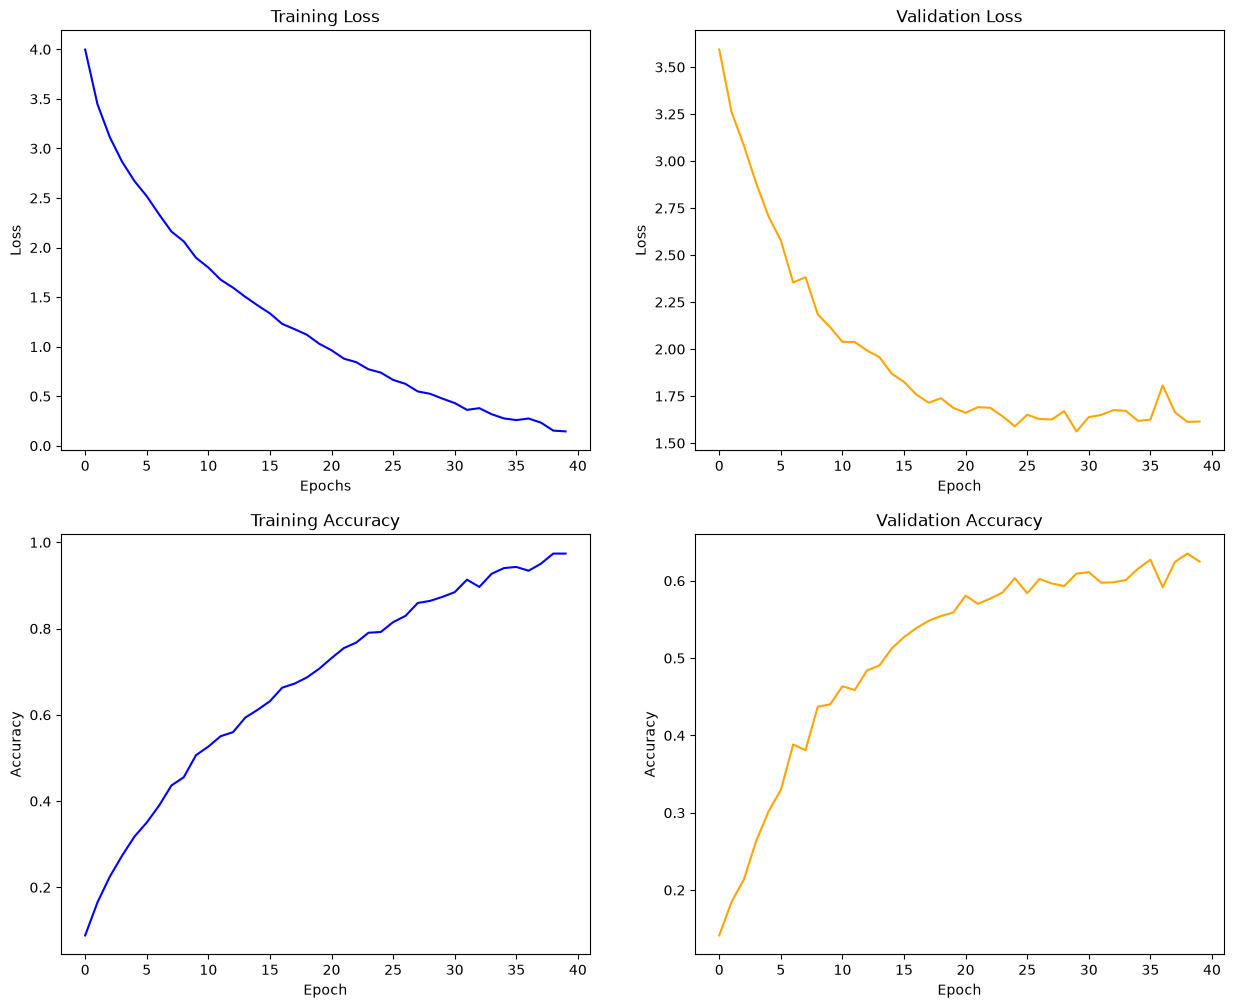

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15, 12))

ax1[0].plot(train_loss_list, color='blue')
ax1[0].set_title('Training Loss')
ax1[0].set_xlabel('Epochs')
ax1[0].set_ylabel('Loss')

ax1[1].plot(val_loss_list, color='orange')
ax1[1].set_title('Validation Loss')
ax1[1].set_xlabel('Epoch')
ax1[1].set_ylabel('Loss')

ax2[0].plot(train_acc_list, color='blue')
ax2[0].set_title('Training Accuracy')
ax2[0].set_xlabel('Epoch')
ax2[0].set_ylabel('Accuracy')

ax2[1].plot(val_acc_list, color='orange')
ax2[1].set_title('Validation Accuracy')
ax2[1].set_xlabel('Epoch')
ax2[1].set_ylabel('Accuracy')


plt.show()

In [10]:
model.eval()

correct = 0
samples = 0

preds = []
true = []


with torch.no_grad():
    for images, labels in test_loader:

        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)
        correct += (predicted == labels).sum().item()
        samples += labels.size(0)

        preds.extend(predicted.tolist())
        true.extend(labels.tolist())

accuracy = correct/samples
print(accuracy)

0.6297747306562194
